<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama y Pulmón</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico: Estudio Comparativo en Cáncer de Mama y Pulmón

**Notebook específico para el EDA y preprocesamiento del conjunto de datos METABRIC (`brca_metabric_clinical_data.tsv`).**

Este cuaderno replica la lógica del notebook de METABRIC y la adapta a la cohorte TCGA:
1. carga y descripción del dataset clínico;
2. EDA reutilizando el módulo `EDA_functions.py`;
3. limpieza orientada a supervivencia;
4. preprocesamiento reproducible para Kaplan-Meier, Cox, Random Survival Forest y DeepSurv.

Para la correcta ejecución del cuaderno necesitaremos importar los siguientes módulos. Las librerías específicas de modelado de supervivencia se importan de forma tolerante: si alguna no está instalada, el preprocesamiento puede ejecutarse igualmente y se mostrará un aviso.

In [1]:
# Sistema
import os
import sys
import warnings

# Ciencia de datos
import numpy as np
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Supervivencia — scikit-survival
from sksurv.util import Surv

# Guardado de modelos
import joblib

# ── Configuración del entorno ────────────────────────────────────────────────
warnings.filterwarnings('ignore')

# Ruta raíz (útil en notebooks)
root_dir = os.path.abspath('..')
sys.path.append(root_dir)

# Configuración de pandas
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Importa y actualiza las funciones personalizadas desde utils.
import importlib
import utils.EDA_functions as eda
importlib.reload(eda)


<module 'utils.EDA_functions' from 'c:\\Users\\jubeda2\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\utils\\EDA_functions.py'>

---

# 1. Estrategia de Adquisición de datos de cáncer de mama y de pulmón

Para evitar lidiar con la complejidad de la API de GDC o las dependencias de R (`TCGAbiolinks`), se extrajeron los datos directamente desde el *Datahub* público de [cBioPortal Datasets](https://www.cbioportal.org/datasets). 

Los identificadores de los conjunstos de datos son:

* **METABRIC (Cáncer de mama):** `brca_metabric_clinical_data`. 
* **TCGA-BRCA (Cáncer de mama):** `brca_tcga_gdc_clinical_data`.
* **TCGA-LUAD (Adenocarcinoma de pulmón) & TCGA-LUSC (Carcinoma escamoso de pulmón):** `nsclc_ctdx_msk_2022_clinical_data`

---

# 2. Cargar los datos clínicos

En este apartado se realiza la carga de los datasets clínicos previamente descargados. Para ello, se emplea un enfoque automatizado que permite leer múltiples archivos en formato `.tsv` y almacenarlos en una estructura de tipo diccionario, donde cada clave corresponde al nombre del dataset y su valor asociado es un *DataFrame* de `pandas`. 

In [3]:
# Definir la lista con las rutas de tus 3 archivos .tsv
rutas_archivos = [
    r"../data/raw/brca_metabric_clinical_data.tsv",
    r"../data/raw/brca_tcga_gdc_clinical_data.tsv",
    r"../data/raw/nsclc_ctdx_msk_2022_clinical_data.tsv"  
]

# Crea el diccionario vacío para almacenar los DataFrames
diccionario_datos = {}

# Bucle para importar y guardar cada archivo
for ruta in rutas_archivos:
    # Extraer el nombre base del archivo y quitarle la extensión '.tsv'
    nombre_clave = os.path.basename(ruta).replace('.tsv', '')
    
    # Leer el .tsv y asignarlo al diccionario
    diccionario_datos[nombre_clave] = pd.read_csv(ruta, sep='\t')

diccionario_datos.keys()  # Mostrar las claves para verificar que se han importado correctamente

dict_keys(['brca_metabric_clinical_data', 'brca_tcga_gdc_clinical_data', 'nsclc_ctdx_msk_2022_clinical_data'])

---

# **3. Breast Cancer (METABRIC, Nature 2012 & Nat Commun 2016)**

El **METABRIC** (*Molecular Taxonomy of Breast Cancer International Consortium*) es uno de los repositorios más robustos y citados en la investigación oncológica. Este conjunto de datos transformó la comprensión del cáncer de mama al integrar perfiles genómicos y transcriptómicos con datos clínicos de seguimiento a muy largo plazo (más de 20 años).

Es el estándar de oro para el **descubrimiento de subtipos moleculares**, el estudio de la heterogeneidad tumoral y el entrenamiento de modelos predictivos de **supervivencia**. Su relevancia radica en la escala de la cohorte y la profundidad de su caracterización multiómica, lo que permite correlacionar alteraciones genéticas específicas con el pronóstico real de las pacientes.

Información complementaria:
* **Enlace de descarga:** [cBioPortal - METABRIC](https://www.cbioportal.org/study/summary?id=brca_metabric)
* **Papers relacionados:** Pereira et al. Nat Commun 2016, Rueda et al. Nature 2019, Curtis et al. Nature 2012.
* **Dataset: `brca_metabric_clinical_data`**
* **Conjuntos de datos completos con Variable, Descripción y Ejemplos**:

| Variable                       | Breve descripción                 | Ejemplos                         |
| ------------------------------ | --------------------------------- | -------------------------------- |
| Study ID                       | Identificador del estudio         | brca_metabric                    |
| Patient ID                     | Identificador único del paciente  | MB-0000, MB-0002                 |
| Sample ID                      | Identificador único de la muestra | MB-0000, MB-0002                 |
| Age at Diagnosis               | Edad en el diagnóstico            | 45.2, 61.1, 72.0                 |
| Type of Breast Surgery         | Tipo de cirugía                   | MASTECTOMY, BREAST CONSERVING    |
| Cancer Type                    | Tipo general de cáncer            | Breast Cancer                    |
| Cancer Type Detailed           | Subtipo de cáncer                 | Breast Invasive Ductal Carcinoma |
| Cellularity                    | Nivel de celularidad              | High, Moderate, Low              |
| Chemotherapy                   | Recibió quimioterapia             | YES, NO                          |
| Pam50 + Claudin-low subtype    | Subtipo molecular                 | LumA, LumB, Her2                 |
| Cohort                         | Cohorte de estudio                | 1, 3, 5                          |
| ER status measured by IHC      | Estado ER por IHC                 | Positive, Negative               |
| ER Status                      | Estado ER                         | Positive, Negative               |
| Neoplasm Histologic Grade      | Grado histológico                 | 1, 2, 3                          |
| HER2 status measured by SNP6   | Estado HER2 SNP6                  | NEUTRAL, GAIN, LOSS              |
| HER2 Status                    | Estado HER2                       | Positive, Negative               |
| Tumor Other Histologic Subtype | Subtipo histológico               | Ductal/NST, Lobular              |
| Hormone Therapy                | Terapia hormonal                  | YES, NO                          |
| Inferred Menopausal State      | Estado menopáusico                | Pre, Post                        |
| Integrative Cluster            | Cluster molecular                 | 3, 4ER+, 8                       |
| Primary Tumor Laterality       | Lado del tumor                    | Left, Right                      |
| Lymph nodes examined positive  | Ganglios positivos                | 0, 2, 10                         |
| Mutation Count                 | Número de mutaciones              | 3, 5, 10                         |
| Nottingham prognostic index    | Índice pronóstico                 | 3.5, 4.0, 5.2                    |
| Oncotree Code                  | Código oncológico                 | IDC, ILC                         |
| Overall Survival (Months)      | Supervivencia (meses)             | 60, 120, 200                     |
| Overall Survival Status        | Estado supervivencia              | 1:DECEASED, 0:LIVING             |
| PR Status                      | Estado PR                         | Positive, Negative               |
| Radio Therapy                  | Radioterapia                      | YES, NO                          |
| Relapse Free Status (Months)   | Tiempo sin recaída                | 40, 100, 200                     |
| Relapse Free Status            | Estado recaída                    | 0:Not Recurred, 1:Recurred       |
| Number of Samples Per Patient  | Nº muestras                       | 1                                |
| Sample Type                    | Tipo de muestra                   | Primary                          |
| Sex                            | Sexo                              | Female                           |
| 3-Gene classifier subtype      | Subtipo genético                  | ER+/HER2- Low Prolif             |
| TMB (nonsynonymous)            | Carga mutacional                  | 3.5, 6.5, 10.2                   |
| Tumor Size                     | Tamaño tumoral                    | 15, 25, 40                       |
| Tumor Stage                    | Estadio                           | 1, 2, 3                          |
| Patient's Vital Status         | Estado vital                      | Living, Died of Disease          |


## **3.1. Descripción  del conjunto de datos**

### **A. Dimensiones y tipo de datos**

El conjunto de datos de la cohorte METABRIC revela la siguiente composición:

* **Dimensiones globales:** El dataset consta de **2.509 registros (filas)** y **39 variables (columnas)**. 
  
* **Tipología de datos:**
    * **Variables numéricas (`float64`, `int64`):** Representan mediciones temporales continuas, parámetros físicos o recuentos absolutos (ej. `Age at Diagnosis`, `Tumor Size`, `Mutation Count`, `Overall Survival (Months)`).
    * **Variables categóricas y de texto (`str`, `object`):** Conforman la mayoría del dataset y recogen clasificaciones clínicas estandarizadas, estados patológicos, identificadores y variables binarias (ej. `Cancer Type Detailed`, `ER Status`, `Overall Survival Status`).

### **B. Valores nulos**

A continuación, se detalla la integridad de los datos organizada por niveles de ausencia:

* **Completitud Total (0% - 1% nulos):** Los identificadores, el tipo de cáncer, el sexo y la carga mutacional (`TMB`) están presentes en la totalidad de los registros. La información sobre recaídas (`Relapse Free Status`) y edad también roza la integridad total.

* **Sesgo de Registro Clínico (3% - 11% nulos):** Las variables patológicas básicas como el estatus de estrógenos (`ER`), el grado histológico, el tamaño tumoral y el conteo de ganglios muestran una alta fiabilidad.

* **Bloque Crítico (~21% nulos):** Existe una falta de información que afecta simultáneamente al **21% de la cohorte**. Este bloque impacta en:
    * **Tratamientos:** Quimioterapia, Hormonoterapia y Radioterapia.
    * **Supervivencia:** El estatus vital y los meses de supervivencia global.
    * **Biomarcadores:** Estatus de HER2, PR y clasificaciones moleculares (Pam50).

* **Máxima Fragmentación (23% - 30% nulos):**
    Las variables de `Cellularity`, `Laterality`, `Tumor Stage` (28.7%) y el clasificador de 3 genes (29.7%) presentan la mayor carencia. 

In [4]:
# Acceder al DataFrame por su clave:
brca_metabric = diccionario_datos['brca_metabric_clinical_data']
eda.describe_df(brca_metabric)

Dimensiones del DataFrame: 2509 filas, 39 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,str,2509,0.00,1,brca_metabric (2509),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,str,2509,0.00,2509,"MB-0000 (1), MB-0002 (1), MB-0005 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,str,2509,0.00,2509,"MB-0000 (1), MB-0002 (1), MB-0005 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Age at Diagnosis,float64,2498,0.44,1843,None,60.420300,61.110000,13.032997,21.93,50.920000,70.000000,96.290000
4,Type of Breast Surgery,str,1955,22.08,2,"MASTECTOMY (1170), BREAST CONSERVING (785)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Cancer Type,str,2509,0.00,1,Breast Cancer (2509),NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type Detailed,str,2509,0.00,8,"Breast Invasive Ductal Carcinoma (1865), Breast Mixed Ductal and Lobular Carcinoma (269), Breast Invasive Lobular Carcinoma (192)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cellularity,str,1917,23.60,3,"High (965), Moderate (737), Low (215)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Chemotherapy,str,1980,21.08,2,"NO (1568), YES (412)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Pam50 + Claudin-low subtype,str,1980,21.08,7,"LumA (700), LumB (475), Her2 (224)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **3.2. Análisis estadístico básico**

En este apartado se realiza un análisis estadístico básico del conjunto de datos `brca_metabric_clinical_data`. El objetivo es explorar las principales características de las variables disponibles, distinguiendo entre variables categóricas y variables numéricas, y agrupándolas según sus familias lógicas (identificadores, metadatos, clinico-demográficos, anatómicas, entre otras).

### **3.2.1. Análisis de Variables Categóricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables categóricas organizadas por familias lógicas:

#### **A. Identificadores y Metadatos del Estudio (Varianza Cero)**
  * **Identificadores Únicos (`Patient ID`, `Sample ID`):** Presentan una cardinalidad máxima (2.509 valores únicos), lo que confirma la ausencia de duplicados y una relación unívoca entre paciente y muestra.
  * **Variables de Varianza Cero (`Study ID`, `Cancer Type`, `Sample Type`, `Sex`):** Estas variables funcionan como constantes en METABRIC. El 100% de la muestra pertenece al estudio METABRIC, son tumores de mama (`Breast Cancer`), de tipo primario (`Primary`) y en pacientes femeninas (`Female`). 

In [35]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Patient ID', 'Sample ID', 'Study ID', 'Cancer Type', 'Sample Type', 'Sex', 'Breast Cancer'])],
    group_name="Identificadores y Metadatos del Estudio",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Identificadores_y_Metadatos_del_Estudio.html


#### **B. Perfil Clínico-Demográfico y Anatómico**
  * **Celularidad (`Cellularity`):** La mayoría de las muestras presentan una celularidad **Alta** (965) o **Moderada** (737), con una minoría de casos bajos (215).
  * **Estado Menopáusico (`Inferred Menopausal State`):** Existe una clara tendencia hacia pacientes **postmenopáusicas** (1.556 casos), lo cual es coherente con la distribución de edad observada en las variables numéricas.
  * **Lateralidad (`Primary Tumor Laterality`):** La distribución es casi simétrica entre la mama izquierda (973) y derecha (897), indicando que el origen anatómico del tumor no presenta un sesgo lateral en esta cohorte.
 

In [6]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Inferred Menopausal State', 'Primary Tumor Laterality', 'Cellularity'])],
    group_name="Perfil Clínico-Demográfico y Anatómico",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Perfil_Clínico-Demográfico_y_Anatómico.html


#### **C. Caracterización Histológica y Patológica**
  * **Clasificación de la Enfermedad (`Cancer Type Detailed`, `Oncotree Code`, `Tumor Other Histologic Subtype`):** Se observa una **dominancia masiva del Carcinoma Ductal Invasivo (IDC)** (1.865 casos), que es el subtipo más común a nivel global. Los subtipos Mixto y Lobular aparecen en frecuencias mucho menores.

In [7]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Cancer Type Detailed', 'Oncotree Code', 'Tumor Other Histologic Subtype'])],
    group_name="Caracterización Histológica y Patológica",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Caracterización_Histológica_y_Patológica.html


#### **D. Biomarcadores Moleculares y Subtipos**
  * **Estado de Receptores (`ER Status`, `PR Status`, `HER2 Status`):** 
      * El perfil predominante es **ER Positivo** (1.825) y **PR Positivo** (1.040).
      * En contraste, el **HER2 Negativo** es la norma (1.733), validado consistentemente por los métodos IHC y SNP6.

  * **Clasificadores Intrínsecos (`Pam50 + Claudin-low`, `3-Gene classifier subtype`, `Integrative Cluster`):** 
      * En el gráfico de `Pam50`, los subtipos **Luminal A** (700) y **Luminal B** (475) son los más frecuentes, alineándose con la positividad de los receptores de estrógeno. 
      * La variable `Integrative Cluster` muestra una distribución más fragmentada en 10 grupos, capturando la heterogeneidad genómica de la enfermedad.

In [8]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['ER Status', 'PR Status', 'HER2 Status', 'Pam50 + Claudin-low subtype', '3-Gene classifier subtype', 'Integrative Cluster', 'ER status measured by IHC', 'HER2 status measured by SNP6'])],
    group_name="Biomarcadores Moleculares y Subtipos",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Biomarcadores_Moleculares_y_Subtipos.html


#### **E. Intervenciones Terapéuticas**
  * **Tratamientos Adyuvantes (`Chemotherapy`, `Hormone Therapy`, `Radio Therapy`):**
      * Existe un fuerte desbalance en **Quimioterapia** (la gran mayoría no la recibió: 1.568 vs 412).
      * La **Terapia Hormonal** (1.216 Sí) y la **Radioterapia** (1.173 Sí) son mucho más comunes, reflejando el estándar de cuidado para tumores Luminales/ER+.
  * **Procedimiento Quirúrgico (`Type of Breast Surgery`):** La tendencia se inclina ligeramente hacia la **Mastectomía** (1.170) frente a la cirugía conservadora (785).

In [9]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Chemotherapy', 'Hormone Therapy', 'Radio Therapy', 'Type of Breast Surgery'])],
    group_name="Intervenciones Terapéuticas",
    dataset_name="METABRIC",
    ncol=2, 
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Intervenciones_Terapéuticas.html


#### **F. Variables Estado de Supervivencia (Variables Objetivo o `Target`):**
  * **Estado de Supervivencia (`Overall Survival Status`, `Patient's Vital Status`):** Se observa una distribución informativa de eventos (aproximadamente el 58% de los pacientes fallecieron (`Decreased`)), que proporciona suficientes datos para el análisis de riesgo.
  * **Estado de Recaída (`Relapse Free Status`):** La mayoría de las pacientes se mantuvieron libres de progresión (`0:Not Recurred`), aunque existe un volumen crítico de 1.002 eventos de recaída para el modelado.

In [10]:
eda.plot_categorical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Overall Survival Status', "Patient's Vital Status", 'Relapse Free Status'])],
    group_name="Variables de Estado de Supervivencia",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Categorical subplots guardado en: ..\images\EDA\METABRIC_cat_Variables_de_Estado_de_Supervivencia.html


### **3.2.2. Análisis de Variables Numéricas: Distribución y Tendencias**

A continuación, se analiza la distribución de las variables numéricas organizadas por familias lógicas:

#### **A. Demografía y Contexto de la Cohorte**

  * **`Age at Diagnosis` (Distribución Gausiana):** Es la variable con el comportamiento más cercano a una distribución normal. Muestra una madurez demográfica clara con una **media de 60.4 años**. Visualmente, el pico de moda se sitúa entre los 60 y 70 años, confirmando que es una cohorte mayoritariamente postmenopáusica, aunque la base ancha del histograma captura casos desde la juventud (21 años) hasta la longevidad extrema (96 años).
  * **`Cohort` (Discreta Multimodal):** Aunque numérica, su gráfico muestra que los datos no son continuos, sino que se agrupan en bloques. La tendencia es descendente, la gran mayoría de los datos provienen de las primeras tres cohortes de recolección, disminuyendo drásticamente en las cohortes 4 a 9.

In [11]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Age at Diagnosis', 'Cohort'])],
    group_name="Demografía y Contexto de la Cohorte",
    dataset_name="METABRIC",
    ncol = 2,
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Demografía_y_Contexto_de_la_Cohorte.html


#### **B. Parámetros Clínico-Patológicos**
  * **`Tumor Size` (Sesgo Positivo):** Presenta una distribución asimétrica hacia la derecha. El grueso de los tumores se concentra entre los **10 y 30 mm**, pero existe una cola larga de casos con tamaños superiores a 100 mm. Esto indica que la mayoría de los tumores son `Tumor Stage` T1/T2, pero hay casos aislados de enfermedad muy avanzada.
  * **`Lymph nodes examined positive` (Sesgo Extremo):** Visualmente, el histograma es una "pared" en el valor 0. La tendencia central es de baja afectación ganglionar, pero los valores atípicos que llegan hasta 45 ganglios positivos representan fenotipos de alta agresividad y riesgo de metástasis.
  * **`Nottingham prognostic index` (Multimodal):** Calcula una nota final combinando tres factores muy importantes: el tamaño del tumor, la cantidad de ganglios linfáticos afectados y el estado del tumor. A diferencia de las otras, esta variable presenta varios picos. Refleja visualmente los tres grupos de pronóstico clínico (bueno, intermedio y pobre). El pico más alto está en torno a un índice de 4, lo que sugiere un riesgo intermedio-alto predominante en la cohorte.
  * `Tumor Stage` y `Neoplasm Histologic Grade`: Aunque codificados numéricamente, actúan como categorías ordinales. El **Estadio 2** y el **Grado 3** son las categorías modales, lo que indica una cohorte donde la enfermedad se suele detectar en fases intermedias pero con características celulares agresivas.

In [12]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Tumor Size', 'Lymph nodes examined positive', 'Nottingham prognostic index', 'Tumor Stage', 'Neoplasm Histologic Grade'])],
    group_name="Parámetros Clínico-Patológicos",
    dataset_name="METABRIC",
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Parámetros_Clínico-Patológicos.html


#### **C. Métricas de Agresividad Molecular**
  * **`Mutation Count` y `TMB (nonsynonymous)`:** Ambas variables son prácticamente idénticas en forma (confirmando su correlación de 1.0). La tendencia es de **baja carga mutacional** (mediana de 5). El hecho de que la gran mayoría de los casos se amontone cerca del cero indica que el cáncer de mama primario es genómicamente "estable" en comparación con otros tejidos, aunque la presencia de outliers sugiere la existencia de un subgrupo hipermutador.

In [13]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Mutation Count', 'TMB (nonsynonymous)'])],
    group_name="Métricas de Agresividad Molecular",
    dataset_name="METABRIC",
    ncol = 2,
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Métricas_de_Agresividad_Molecular.html


#### **D. Variables Temporales de Supervivencia (Variables Objetivo o `Target`)**
  * **`Overall Survival (Months)` y `Relapse Free Status (Months)`:** Ambas muestran distribuciones muy similares con una base muy extensa. La frecuencia de supervivencia se mantiene relativamente alta y constante hasta los 150-200 meses, donde empieza a decaer. La cola llega hasta los **350 meses**, lo que visualmente demuestra un seguimiento clínico excepcional de casi 30 años.

In [14]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Overall Survival (Months)', 'Relapse Free Status (Months)'])],
    group_name="Métricas de Supervivencia",
    dataset_name="METABRIC", ncol = 2,
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Métricas_de_Supervivencia.html


#### **E. Variables de Estructura (Varianza Cero)**
  * **`Number of Samples Per Patient`:** El histograma muestra una única barra masiva en el valor 1. Esto confirma visualmente la granularidad del dataset, un registro por paciente, eliminando la necesidad de modelos de medidas repetidas.

In [36]:
eda.plot_numerical_subplots(
    df=brca_metabric.loc[:, brca_metabric.columns.isin(['Number of Samples Per Patient'])],
    group_name="Variables de Estructura",
    dataset_name="METABRIC", ncol=1,
    output_path=r"..\images\EDA"
)

✔ Numerical subplots guardado en: ..\images\EDA\METABRIC_num_subplots_Variables_de_Estructura.html


### **3.2.3. Análisis de Correlaciones (Heatmap)**

A continuación, se analiza las correlaciones de las variables numéricas (excepto `Number of Samples Per Patient`):

#### **A. Relaciones de Dependencia y Redundancia (Alta Correlación)**
* **`TMB` vs `Mutation Count` (1.00):** Existe una correlación perfecta. Esto indica que ambas variables miden el mismo fenómeno biológico en este dataset. 
* **`Overall Survival` vs `Relapse Free Status` (0.90):** Una correlación positiva muy fuerte que valida la lógica clínica: los pacientes que tardan más en recaer son, sistemáticamente, los que presentan una mayor supervivencia global.
* **`Nottingham Prognostic Index` (NPI) y Gravedad:** El NPI muestra correlaciones sólidas con el `Neoplasm Histologic Grade` (**0.70**) y el `Tumor Stage` (**0.55**). Esto confirma visualmente que el NPI funciona como una métrica compuesta que integra la agresividad celular y la extensión del tumor.

#### **B. Relaciones Inversas con la Supervivencia (Impacto Pronóstico)**
* **Variables de Gravedad vs Supervivencia:** Se observa una tendencia de correlación negativa entre los meses de vida (`Overall Survival`) y factores como el `Tumor Stage` (**-0.27**), el `Nottingham prognostic index` (**-0.24**) y el `Tumor Size` (**-0.19**). Aunque los valores absolutos parecen moderados, confirman que a medida que aumentan estos índices de gravedad, el tiempo de supervivencia tiende a disminuir.

#### **C. Independencia de Variables (Baja Correlación)**
* **`Age at Diagnosis`:** Presenta una correlación cercana a cero con casi todas las métricas moleculares y patológicas (ej. **0.03** con `Mutation Count` o **0.06** con `Tumor Size`). Esto sugiere que la agresividad del tumor en METABRIC es independiente de la edad de la paciente al momento del diagnóstico.
* **`Cohort`:** No muestra relaciones significativas con las variables clínicas, lo que indica que el proceso de recolección de muestras no introdujo sesgos sistemáticos en variables críticas como el tamaño o el grado tumoral.

✔ Heatmap guardado en: ../images/EDA\METABRIC_heatmap_correlaciones.png


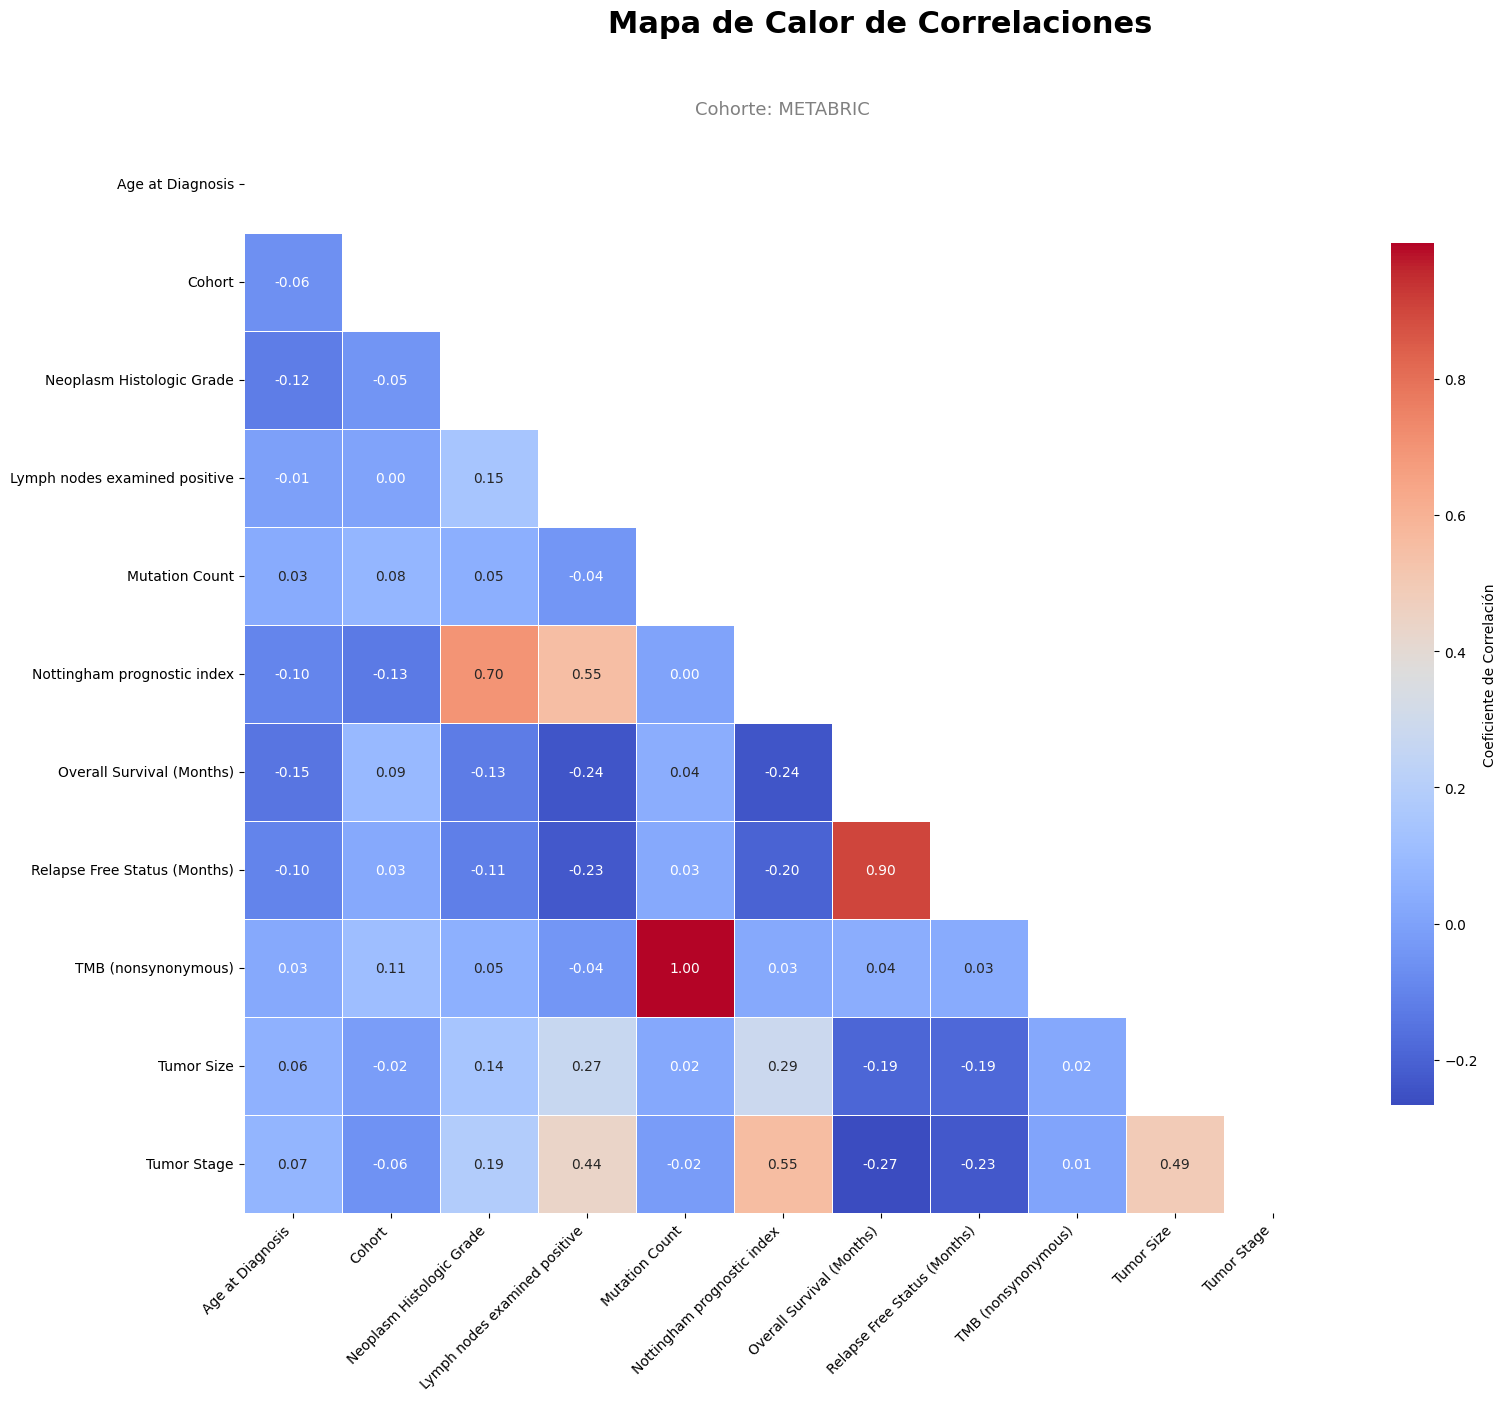


════════════════════════════════════════════════════════════════════════════════
  Resumen de Correlaciones — METABRIC (Pearson)
════════════════════════════════════════════════════════════════════════════════
  Etiqueta   Par de variables                                                  Corr
  ────────── ────────────────────────────────────────────────────────────── ───────
  ▲ Top 1    TMB (nonsynonymous)  ↔  Mutation Count                          0.9992
  ▲ Top 2    Relapse Free Status (Months)  ↔  Overall Survival (Months)      0.9023
  ▲ Top 3    Nottingham prognostic index  ↔  Neoplasm Histologic Grade       0.6997
  ▲ Top 4    Tumor Stage  ↔  Nottingham prognostic index                     0.5543
  ▲ Top 5    Nottingham prognostic index  ↔  Lymph nodes examined positive   0.5510
  ·········· ······························································ ·······
  ▼ Bot 1    Tumor Stage  ↔  Overall Survival (Months)                      -0.2666
  ▼ Bot 2    Overall Survival (Mo

In [16]:
eda.plot_correlation_heatmap(
    df=brca_metabric.loc[:, brca_metabric.columns != "Number of Samples Per Patient"],
    dataset_name="METABRIC",
    output_path="../images/EDA"
)

## **3.3. Preprocesado de los datos**

Una vez analizados los atributos descriptivos, se prepararon para que nos sean útiles de cara a predecir valores.

In [17]:
# Trabajamos sobre una copia para no modificar el DataFrame del EDA
brca_prep = brca_metabric.copy()
print(f"Shape inicial: {brca_prep.shape}")

Shape inicial: (2509, 39)


### **3.3.1. Eliminación de columnas de varianza cero y metadatos irrelevantes**

Las variables `Study ID`, `Cancer Type`, `Sample Type`, `Sex` y `Number of Samples Per Patient` presentan un único valor en toda la cohorte (varianza cero). No aportan ningún poder discriminativo a ningún modelo predictivo.

In [18]:
COLS_DROP_METADATA = [
    'Study ID',                       # constante: 'brca_metabric'
    'Cancer Type',                    # constante: 'Breast Cancer'
    'Sample Type',                    # constante: 'Primary'
    'Sex',                            # constante: 'Female'
    'Number of Samples Per Patient',  # constante: 1
    'Patient ID',                     # identificador único
    'Sample ID',                      # identificador único
]

brca_prep.drop(columns=COLS_DROP_METADATA, inplace=True, errors='ignore')

print(f"Columnas eliminadas ({len(COLS_DROP_METADATA)}) : {COLS_DROP_METADATA}")
print(f"Shape resultante    : {brca_prep.shape}")

Columnas eliminadas (7) : ['Study ID', 'Cancer Type', 'Sample Type', 'Sex', 'Number of Samples Per Patient', 'Patient ID', 'Sample ID']
Shape resultante    : (2509, 32)


### **3.3.2. Eliminación de variables redundantes e inadecuadas**

El EDA reveló tres casos de redundancia:

- **`TMB (nonsynonymous)` ~ `Mutation Count` (r = 0.999):** Son la misma métrica expresada en escalas diferentes. Mantener ambas inflaría artificialmente el peso de la carga mutacional en los modelos. `Mutation Count` se eliminó en favor de `TMB (nonsynonymous)` por tener una menor cantidad de valores nulos.
- **`Oncotree Code`, `Tumor Other Histologic Subtype` y `Cancer Type Detailed`:** Codifican la misma clasificación histológica. Se elimina `Oncotree Code` por ser más críptico.
- **`Overall Survival Status` ~ `Patient's Vital Status`:** Ambas capturan el estado vital. La primera es el estándar binario para análisis de supervivencia. `Patient's Vital Status` aporta granularidad adicional (distingue causa de muerte) pero se gestiona en el siguiente paso.

No todas las variables restantes son adecuadas como covariables. Se excluyen:

- **Variables que son parte del endpoint** (`Relapse Free Status`, `Relapse Free Status (Months)`): su inclusión como covariable causaría *data leakage* directo.
- **Variables de alta cardinalidad post-EDA** (`Cohort`): tiene 9 categorías con distribución muy sesgada hacia las primeras 3 y no aporta valor pronóstico clínico.

In [19]:
COLS_REDUNDANTES = [
    'Mutation Count',   
    'Oncotree Code',    
    'Patient\'s Vital Status',  
    'Tumor Other Histologic Subtype', 
    'ER status measured by IHC',
    'HER2 status measured by SNP6',
]

COLS_LEAKAGE = [
    'Relapse Free Status',
    'Relapse Free Status (Months)',
    'Cohort',
]

COLS_REDUNDANTES_LEAKAGE = COLS_REDUNDANTES + COLS_LEAKAGE

brca_prep.drop(columns=COLS_REDUNDANTES_LEAKAGE, inplace=True, errors='ignore')

print(f"Columnas eliminadas ({len(COLS_REDUNDANTES_LEAKAGE)}) : {COLS_REDUNDANTES_LEAKAGE}")
print(f"Shape resultante    : {brca_prep.shape}")

Columnas eliminadas (9) : ['Mutation Count', 'Oncotree Code', "Patient's Vital Status", 'Tumor Other Histologic Subtype', 'ER status measured by IHC', 'HER2 status measured by SNP6', 'Relapse Free Status', 'Relapse Free Status (Months)', 'Cohort']
Shape resultante    : (2509, 23)


### **3.3.3. Definición y *parsing* de las variables objetivo (`duration` y `event`)**

Todos los modelos de análisis de supervivencia requieren dos variables objetivo bien definidas:
- **`duration`** (`T`): tiempo hasta el evento o hasta la censura, en unidades consistentes (meses).
- **`event`** (`E`): indicador binario booleano donde `True` = evento ocurrido (muerte) y `False` = censurado (vivo al final del seguimiento).

La columna `Overall Survival Status` viene en formato string `"1:DECEASED"` / `"0:LIVING"`, que debe parsearse a entero. Se opta por `Overall Survival` como endpoint primario (muerte por cualquier causa), que es el más robusto y estándar en oncología.

In [20]:
brca_prep['duration'] = brca_prep['Overall Survival (Months)'].copy()

brca_prep['event'] = (
    brca_prep['Overall Survival Status']
    .astype(str)
    .str.extract(r'^(\d)')[0]
    .astype(float)
)

TARGET_COLS   = ['duration', 'event']

# Verificación
eda.describe_df(brca_prep[TARGET_COLS])

Dimensiones del DataFrame: 2509 filas, 2 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,duration,float64,1981,21.04,1743,None,125.244271,116.466667,76.111772,0.0,60.866667,185.133333,355.2
1,event,float64,1981,21.04,2,None,0.577486,1.000000,0.494084,0.0,0.000000,1.000000,1.0


In [21]:
print(f"Columnas creadas ({len(TARGET_COLS)}) : {TARGET_COLS}")
print(f"Shape resultante    : {brca_prep.shape}")

print(f"\nDistribución del evento:\n{brca_prep['event'].value_counts()}")
print(f"Tasa de eventos (censura): {brca_prep['event'].mean():.2%}")

Columnas creadas (2) : ['duration', 'event']
Shape resultante    : (2509, 25)

Distribución del evento:
event
1.0    1144
0.0     837
Name: count, dtype: int64
Tasa de eventos (censura): 57.75%


### 3.3.4. Eliminación de registros con valores nulos en las variables objetivo

Aproximadamente el 21% de los registros carecen de información de supervivencia (`Overall Survival (Months)` y `Overall Survival Status`). Imputar el tiempo o el estado del evento es metodológicamente inaceptable en análisis de supervivencia, equivaldría a inventar si alguien murió o cuándo. Por este motivo, se eliminan aquellos registros con valores nulos en las variables objetivo.

In [22]:
n_antes = len(brca_prep)

brca_prep.dropna(subset=['duration', 'event'], inplace=True)

COLS_POST_TARGET = [
    'Overall Survival (Months)',
    'Overall Survival Status',
]
brca_prep.drop(columns=COLS_POST_TARGET, inplace=True, errors='ignore')


print(f"Columnas eliminadas ({len(COLS_POST_TARGET)}) : {COLS_POST_TARGET}")
print(f"Shape resultante    : {brca_prep.shape}")
print(f"Registros eliminados : {n_antes - len(brca_prep)} ({(n_antes - len(brca_prep)) / n_antes:.1%})")
print(f"Registros restantes  : {len(brca_prep)}")

Columnas eliminadas (2) : ['Overall Survival (Months)', 'Overall Survival Status']
Shape resultante    : (1981, 23)
Registros eliminados : 528 (21.0%)
Registros restantes  : 1981


### 3.3.5. Tratamiento de tiempos de supervivencia en cero

Un tiempo de supervivencia de `T = 0` es problemático en los modelos de Cox debido a que usa logaritmos del tiempo en sus cálculos internos (log(0) = −$\infty$), y RSF no puede establecer un split temporal válido. Estos casos suelen representar muertes ocurridas en el mismo mes del diagnóstico o errores de registro. La solución tomada ha sido desplazar estos tiempos a un valor mínimo de `0.001` meses (aproximadamente 43 minutos), preservando el registro sin distorsionar la escala clínica.

In [23]:
EPSILON = 0.001

n_ceros = (brca_prep['duration'] == 0).sum()
brca_prep['duration'] = brca_prep['duration'].clip(lower=EPSILON)

print(f"Registros con T=0 corregidos : {n_ceros}")
print(f"Tiempo mínimo tras corrección: {brca_prep['duration'].min():.4f} meses")
print(f"Tiempo máximo                : {brca_prep['duration'].max():.2f} meses")

Registros con T=0 corregidos : 1
Tiempo mínimo tras corrección: 0.0010 meses
Tiempo máximo                : 355.20 meses


### 3.3.6. Selección del subconjunto de covariables para el modelado

A continuación se seleccionan las variables objetivo y las descriptivas para el modelado:

In [24]:
# Separar covariables de las variables objetivo
FEATURE_COLS  = [c for c in brca_prep.columns if c not in TARGET_COLS]

print(f"Covariables candidatas ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Shape resultante      : {brca_prep.shape}")

Covariables candidatas (21): ['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER Status', 'Neoplasm Histologic Grade', 'HER2 Status', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive', 'Nottingham prognostic index', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype', 'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage']
Shape resultante      : (1981, 23)


### **3.3.7. División estratificada en conjuntos train/test**

Se usa una partición **80/20** con estratificación por el indicador de evento. La estratificación es crítica en análisis de supervivencia porque una partición aleatoria simple podría generar un conjunto de test con una tasa de censura muy distinta a la del train, haciendo que las métricas de evaluación (C-index, Brier Score) sean poco representativas del rendimiento real. El `random_state` fijo garantiza la reproducibilidad de todos los experimentos del TFM.

In [25]:
X = brca_prep[FEATURE_COLS].copy()
y_duration = brca_prep['duration'].values
y_event    = brca_prep['event'].values

X_train, X_test, dur_train, dur_test, evt_train, evt_test = train_test_split(
    X, y_duration, y_event,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y_event.astype(int)
)

print(f"Train : {len(X_train)} registros | Tasa de eventos: {evt_train.mean():.2%}")
print(f"Test  : {len(X_test)}  registros | Tasa de eventos: {evt_test.mean():.2%}")

Train : 1584 registros | Tasa de eventos: 57.77%
Test  : 397  registros | Tasa de eventos: 57.68%


### **3.3.8. Imputación de valores nulos en covariables**

 La estrategia de imputación difiere según el tipo:

- **Variables numéricas continuas -> mediana:** Robusta frente a los outliers detectados en `Tumor Size` y `Lymph nodes examined positive`. La media se vería distorsionada por la cola larga de esas distribuciones.
- **Variables ordinales numéricas (`Tumor Stage`, `Neoplasm Histologic Grade`) -> mediana** por la misma razón que las continuas.
- **Variables categóricas nominales -> categoría `"Unknown"`:** Preserva la ausencia de información como un estado válido y evita asumir que el valor más frecuente es correcto cuando el dato falta. Kaplan-Meier y RSF pueden manejar una categoría `"Unknown"` explícitamente, mientras que Cox la incorporará como nivel de referencia.

> `fit` únicamente sobre train, `transform` sobre ambos. 

In [26]:
NUM_COLS = X_train.select_dtypes(include='number').columns.tolist()
CAT_COLS = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables numéricas  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nVariables categóricas ({len(CAT_COLS)}): {CAT_COLS}")

Variables numéricas  (7): ['Age at Diagnosis', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Nottingham prognostic index', 'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage']

Variables categóricas (14): ['Type of Breast Surgery', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER Status', 'HER2 Status', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype']


In [27]:
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')

X_train[NUM_COLS] = imputer_num.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = imputer_num.transform(X_test[NUM_COLS])

X_train[CAT_COLS] = imputer_cat.fit_transform(X_train[CAT_COLS])
X_test[CAT_COLS]  = imputer_cat.transform(X_test[CAT_COLS])

### **3.3.9. Tratamiento de outliers en variables numéricas continuas**

El EDA mostró colas largas en `Tumor Size` (hasta 182 mm) y `Lymph nodes examined positive` (hasta 45). En Cox, los outliers extremos pueden desestabilizar las estimaciones de los coeficientes $\beta$. En DeepSurv, los gradientes durante el entrenamiento son sensibles a rangos muy amplios. Se aplica **winsorización al percentil 1–99** (en lugar de eliminar registros). De este modo se recortan los valores más extremos al umbral del percentil, preservando toda la información pero eliminando el efecto desproporcionado de los casos atípicos.

> Los percentiles se calculan sobre train y se aplican en test.

In [28]:
COLS_WINSORIZE = [
    'Tumor Size',
    'Lymph nodes examined positive',
    'TMB (nonsynonymous)',
]

winsor_limits = {}

for col in COLS_WINSORIZE:
    if col in X_train.columns:
        p01 = np.percentile(X_train[col], 1)
        p99 = np.percentile(X_train[col], 99)
        winsor_limits[col] = (p01, p99)

        X_train[col] = X_train[col].clip(lower=p01, upper=p99)
        X_test[col]  = X_test[col].clip(lower=p01, upper=p99)

        print(f"{col:<40} -> clipped a [{p01:.2f}, {p99:.2f}]")

Tumor Size                               -> clipped a [3.83, 84.17]
Lymph nodes examined positive            -> clipped a [0.00, 18.00]
TMB (nonsynonymous)                      -> clipped a [0.00, 25.07]


### **3.3.10. Codificación de variables categóricas**

Cox, RSF y DeepSurv no procesan strings. Se usa OHE con `drop='first'` para evitar la trampa de la variable dummy (multicolinealidad perfecta) y `handle_unknown='ignore'` para que categorías nuevas en test no rompan el pipeline.

- ***One-Hot Encoding (OHE)*** para variables **nominales** sin orden intrínseco.

> El encoder se ajusta SOLO sobre train.

In [29]:
encoder = OneHotEncoder(
    drop           = 'first',
    sparse_output  = False,
    handle_unknown = 'ignore',
    dtype          = float
)

# Ajustar y transformar
ohe_train = encoder.fit_transform(X_train[CAT_COLS])
ohe_test  = encoder.transform(X_test[CAT_COLS])

# Nombres de las nuevas columnas
ohe_feature_names = encoder.get_feature_names_out(CAT_COLS).tolist()

# Construir DataFrames con las columnas OHE
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
ohe_test_df  = pd.DataFrame(ohe_test,  columns=ohe_feature_names, index=X_test.index) # type: ignore

# Reemplazar columnas categóricas originales por las OHE
X_train = pd.concat([X_train.drop(columns=CAT_COLS), ohe_train_df], axis=1)
X_test  = pd.concat([X_test.drop(columns=CAT_COLS),  ohe_test_df],  axis=1)

print(f"Shape X_train tras OHE: {X_train.shape}")
print(f"Shape X_test  tras OHE: {X_test.shape}")
print(f"Total covariables finales: {X_train.shape[1]}")

Shape X_train tras OHE: (1584, 56)
Shape X_test  tras OHE: (397, 56)
Total covariables finales: 56


### **3.3.11. Escalado de variables numéricas**

La necesidad del escalado varía por modelo:
- **Kaplan-Meier:** No usa covariables, no requiere escalado.
- **Cox PH:** Técnicamente puede funcionar sin escalar, pero el escalado mejora la interpretabilidad de los coeficientes y la convergencia del optimizador (especialmente con variables en rangos muy distintos como `Age` en años versus `Nottingham prognostic index`).
- **RSF (Random Survival Forest):** Los árboles son invariantes al escalado monótono, por lo que **no es estrictamente necesario**, pero escalar facilita la comparabilidad con los otros modelos en un pipeline unificado.
- **DeepSurv:** **Obligatorio.** Las redes neuronales son muy sensibles a la escala de las entradas. Sin normalización, las neuronas de las capas iniciales se saturan y el gradiente desaparece.

Se aplica `StandardScaler` (media=0, std=1) solo sobre las columnas numéricas originales.

In [30]:
scaler = StandardScaler()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])

In [31]:
print(f"Variables escaladas ({len(NUM_COLS)}): {NUM_COLS}")
eda.describe_df(X_train[NUM_COLS])[['Column', 'mean', 'std']]

Variables escaladas (7): ['Age at Diagnosis', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Nottingham prognostic index', 'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage']
Dimensiones del DataFrame: 1584 filas, 7 columnas



,Column,mean,std
0,Age at Diagnosis,1.637299e-16,1.000316
1,Neoplasm Histologic Grade,-1.536369e-16,1.000316
2,Lymph nodes examined positive,1.345725e-17,1.000316
3,Nottingham prognostic index,6.560409e-17,1.000316
4,TMB (nonsynonymous),2.411090e-16,1.000316
5,Tumor Size,8.298637e-17,1.000316
6,Tumor Stage,-7.513631e-17,1.000316


### 3.3.12. Creación del `structured array` de scikit-survival

La librería `scikit-survival` requiere que la variable objetivo esté en un formato específico, como un **numpy structured array** con dos campos nombrados, `event` (booleano) y `time` (float). 

In [32]:
y_train = Surv.from_arrays(
    event = evt_train.astype(bool),
    time  = dur_train.astype(float)
)

y_test = Surv.from_arrays(
    event = evt_test.astype(bool),
    time  = dur_test.astype(float)
)

# Arrays en formato numpy para DeepSurv / lifelines
X_train_np = X_train.values.astype(float)
X_test_np  = X_test.values.astype(float)

print(f"y_train dtype : {y_train.dtype}  | shape: {y_train.shape}")
print(f"y_test  dtype : {y_test.dtype}   | shape: {y_test.shape}")
print(f"X_train_np    : {X_train_np.shape}")
print(f"X_test_np     : {X_test_np.shape}")

y_train dtype : [('event', '?'), ('time', '<f8')]  | shape: (1584,)
y_test  dtype : [('event', '?'), ('time', '<f8')]   | shape: (397,)
X_train_np    : (1584, 56)
X_test_np     : (397, 56)


### 3.3.13. Guardado del pipeline para el módulo de modelos 

In [33]:
SAVE_DIR = '../data/processed/metabric'
os.makedirs(SAVE_DIR, exist_ok=True)

brca_prep.to_csv(f'{SAVE_DIR}/brca_metabric_preprocessed.csv', index=False)

In [34]:
SAVE_DIR = '../data/processed/metabric'
os.makedirs(SAVE_DIR, exist_ok=True)

# X — covariables
np.save(f'{SAVE_DIR}/X_train_np.npy', X_train_np)
np.save(f'{SAVE_DIR}/X_test_np.npy',  X_test_np)

# y — tiempos y eventos por separado
np.save(f'{SAVE_DIR}/dur_train.npy',  dur_train)
np.save(f'{SAVE_DIR}/dur_test.npy',   dur_test)
np.save(f'{SAVE_DIR}/evt_train.npy',  evt_train)
np.save(f'{SAVE_DIR}/evt_test.npy',   evt_test)

# y — structured arrays (scikit-survival no acepta arrays separados)
joblib.dump(y_train, f'{SAVE_DIR}/y_train.pkl')
joblib.dump(y_test,  f'{SAVE_DIR}/y_test.pkl')

# X — DataFrame con nombres de columnas (lifelines lo requiere)
X_train.to_parquet(f'{SAVE_DIR}/X_train_df.parquet')
X_test.to_parquet(f'{SAVE_DIR}/X_test_df.parquet')

print("✓ Datos guardados en:", SAVE_DIR)

✓ Datos guardados en: ../data/processed/metabric
